<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning </b></center>

<center><b><h1>Lab - 5</b></center>    
<pre>    

# Dataset - `Position_Salaries.csv`

# 1. Import Libraries: 
## Import the necessary libraries (numpy, seaborn, pandas).

In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset: 
## Import the dataset (likely `Position_Salaries.csv` based on the data shown)

In [29]:
df = pd.read_csv('Position_Salaries.csv')

In [30]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


# 3. Visualisation: Plot the data using a `scatter plot` to understand 
## the relationship between Position `Level` and `Salary`.

<Axes: xlabel='Level', ylabel='Salary'>

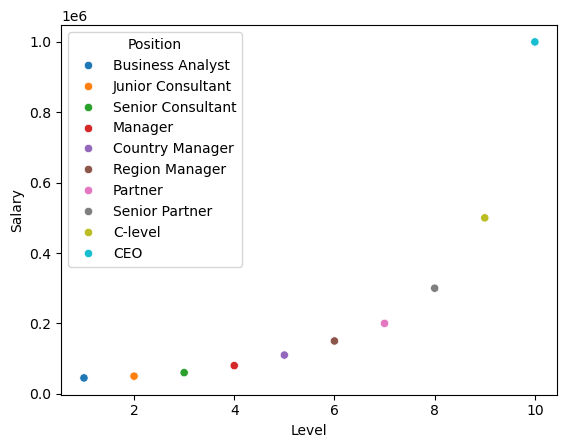

In [31]:
sns.scatterplot(x=df['Level'],y=df["Salary"],hue=df['Position'])

# 4. Data Splitting: `Split` the dataset into the Training set and Test set.

In [59]:
X = df[['Level']]
y = df['Salary']

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

# 5. Linear Regression Training: 
## Fit a Simple `LinearRegression` model to the dataset.

In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
model = LinearRegression()

In [64]:
model.fit(X_train,y_train)

LinearRegression()

# 6. Linear Regression Prediction: 
## Predict the test set results using the Linear Regression model.

In [65]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import mean_squared_error ,r2_score

In [67]:
r2 = r2_score(y_test,y_pred) * 100
r2

84.51346684575974

In [68]:
mse =mean_squared_error(y_test,y_pred)

In [69]:
mse

7840057409.334131

In [70]:
rmse = np.sqrt(mse)
rmse

np.float64(88544.09867029045)

# 7. Linear Regression Visualization: 
## Visualize the Simple Linear Regression results (plot the regression line against the scatter plot)

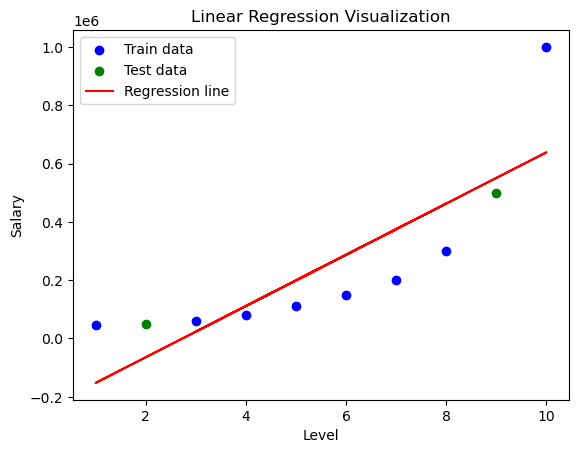

In [73]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Scatter plot (real data)
plt.scatter(X_train, y_train, color='blue', label='Train data')
plt.scatter(X_test, y_test, color='green', label='Test data')

# Regression line (IMPORTANT)
plt.plot(X_train, y_train_pred, color='red', label='Regression line')

plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Linear Regression Visualization")
plt.legend()
plt.show()

# Polynomial Regression

## 8.Polynomial Feature Generation:
  #### ○ **Import PolynomialFeatures from `sklearn.preprocessing.`**
  #### ○ **Create a PolynomialFeatures object with `degree 4`.**
  #### ○ **Apply `fit_transform` to the feature variable `(X)` to generate the polynomial features**

In [88]:
from sklearn.preprocessing import PolynomialFeatures

# Create Polynomial Features (degree = 4)
poly = PolynomialFeatures(degree=4)

# Transform X into polynomial features
X_poly = poly.fit_transform(X)

# 9. Polynomial Regression Training: 
## Fit a `LinearRegression` model using the new `polynomial features.`

In [89]:
from sklearn.linear_model import LinearRegression

# Train model on polynomial features
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y)

LinearRegression()

# 9. Grid Creation: 
**Create a grid for the X values (higher resolution) to generate a smoother curve for visualization.**

In [96]:
import numpy as np

# Create high-resolution X grid
X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid) #Transform grid for polynomial model

# 10. Polynomial Prediction:
## Predict the values using the Polynomial Regression model.

In [92]:
# Predictions for smooth curve
y_grid_pred = lr_poly.predict(X_grid_poly)

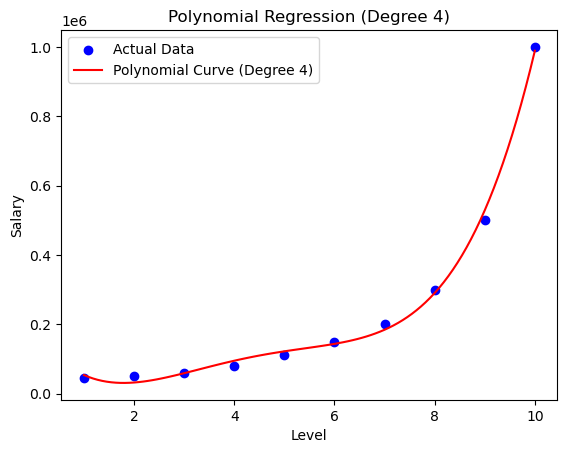

In [93]:
# Actual data points
plt.scatter(X, y, color='blue', label='Actual Data')

# Smooth polynomial curve
plt.plot(X_grid, y_grid_pred, color='red', label='Polynomial Curve (Degree 4)')

# Labels
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression (Degree 4)")
plt.legend()

plt.show()